In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv(r"C:\Users\KIIT\Desktop\portfolio\Projects\Logistics and supply chain dataset\dynamic_supply_chain_logistics_dataset.csv")

In [3]:
import pandas as pd
# Isse saare columns screen par dikhne lagenge
pd.set_option('display.max_columns', None)

# Ab jab aap df.head() ya df.info() karenge, toh kuch bhi nahi chhupega
print(df.columns.tolist())

['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation']


In [4]:
print("Dataset Shape:", df.shape)
print("\nSample Data:")
display(df.head())
print("\nData Types & Info:")
print(df.info())

Dataset Shape: (32065, 26)

Sample Data:


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,0.359066,4.289160,456.503853,0.986064,2.128009,100.772854,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,0.230660,7.018373,640.408205,0.463233,12.608166,5313.738114,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,0.027210,9.605064,155.749314,0.598561,14.124452,1595.049146,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,0.616619,8.899616,104.317961,0.742735,3.818972,2530.431941,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,0.952385,0.061760,977.222528,0.431088,14.001491,2146.190197,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484



Data Types & Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12

In [5]:
df.describe()

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
count,32065.000000,32065.000000,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,3.206500e+04,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,32065.000000,32065.000000
mean,38.023589,-90.116648,8.011735,2.893068,4.991493e+00,2.992547e+02,2.291669,3.026954e-01,0.600740,4.976082e-01,6.978414,459.374452,5.008499e-01,5.227502,6022.001286,0.044792,2.972816e-01,7.001144,2.296448,4.983913e-01,6.008723e-01,0.803656,0.699077,5.177648
std,6.917909,17.369244,4.264960,2.274044,3.532048e+00,3.234435e+02,1.554202,3.259146e-01,0.345672,3.532853e-01,3.251051,312.183487,3.535281e-01,4.523085,3427.638017,14.187486,3.216115e-01,3.236328,1.555932,3.541589e-01,3.458101e-01,0.279185,0.324514,4.157988
min,30.000000,-119.999998,5.000000,-1.999993,1.091633e-09,1.322210e-12,0.500000,4.565769e-16,0.000001,4.536949e-09,0.000002,100.000000,6.904319e-10,1.000000,100.002966,-10.000000,7.255415e-19,0.000050,0.500000,4.043927e-09,3.269508e-07,0.000048,0.000003,-1.999998
25%,31.280550,-106.253913,5.019984,1.185744,1.474720e+00,1.605163e+01,0.774798,1.710828e-02,0.277096,1.440135e-01,4.513889,154.017124,1.453158e-01,1.237490,2822.607616,-9.931074,1.678269e-02,4.593407,0.776166,1.443567e-01,2.783148e-01,0.693739,0.456009,1.269197
50%,36.413820,-86.293414,5.636036,3.882059,4.981244e+00,1.572880e+02,1.917121,1.595151e-01,0.680553,4.961781e-01,8.383225,388.996911,5.032655e-01,3.297654,6785.123209,-7.858681,1.549760e-01,8.385605,1.938273,4.988468e-01,6.831130e-01,0.958128,0.839599,6.113662
75%,44.453655,-73.079367,9.669944,4.884355,8.534902e+00,5.405980e+02,3.734188,5.535954e-01,0.938160,8.498226e-01,9.838150,753.007203,8.539780e-01,8.625720,9374.252913,6.024012,5.405408e-01,9.836152,3.750817,8.510762e-01,9.372889e-01,0.998746,0.982391,9.249206
max,50.000000,-70.000000,19.999875,5.000000,9.999999e+00,9.999993e+02,5.000000,9.999995e-01,1.000000,1.000000e+00,10.000000,999.999853,1.000000e+00,14.999995,10000.000000,39.999886,1.000000e+00,10.000000,5.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,10.000000


In [6]:
#1.Time features
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.dayofweek

In [7]:
# 2. Target Variable (Buckets) banana
df['delay_bucket'] = pd.cut(df['delivery_time_deviation'], 
                            bins=[-np.inf, 2, 8, np.inf], 
                            labels=['Low Delay', 'Medium Delay', 'High Delay'])

In [8]:
# 3. Missing Values handle
df = df.fillna(df.median(numeric_only=True))

print("Target Buckets Created:\n", df['delay_bucket'].value_counts())

Target Buckets Created:
 delay_bucket
High Delay      11974
Medium Delay    10867
Low Delay        9224
Name: count, dtype: int64


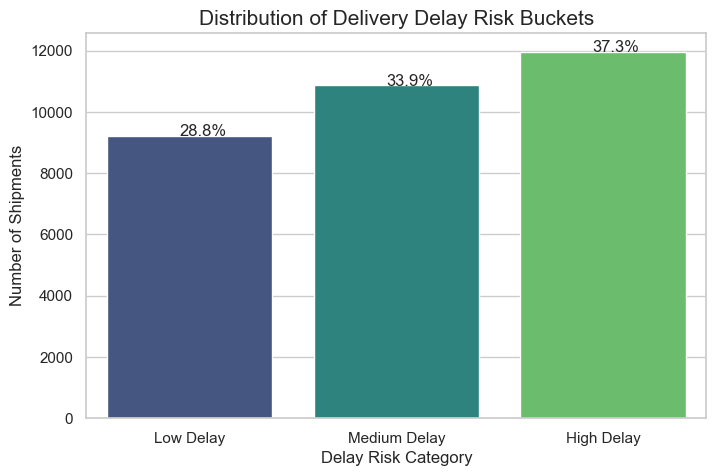

In [9]:
# 1. Target Variable Analysis (Delay Buckets)
# ---------------------------------------------------------
# Understanding the balance of our classes (Low, Medium, High Delay)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='delay_bucket', data=df, palette='viridis', order=['Low Delay', 'Medium Delay', 'High Delay'])
plt.title('Distribution of Delivery Delay Risk Buckets', fontsize=15)
plt.xlabel('Delay Risk Category', fontsize=12)
plt.ylabel('Number of Shipments', fontsize=12)

# Adding percentage labels on top of bars
total = len(df['delay_bucket'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), size = 12)
plt.show()

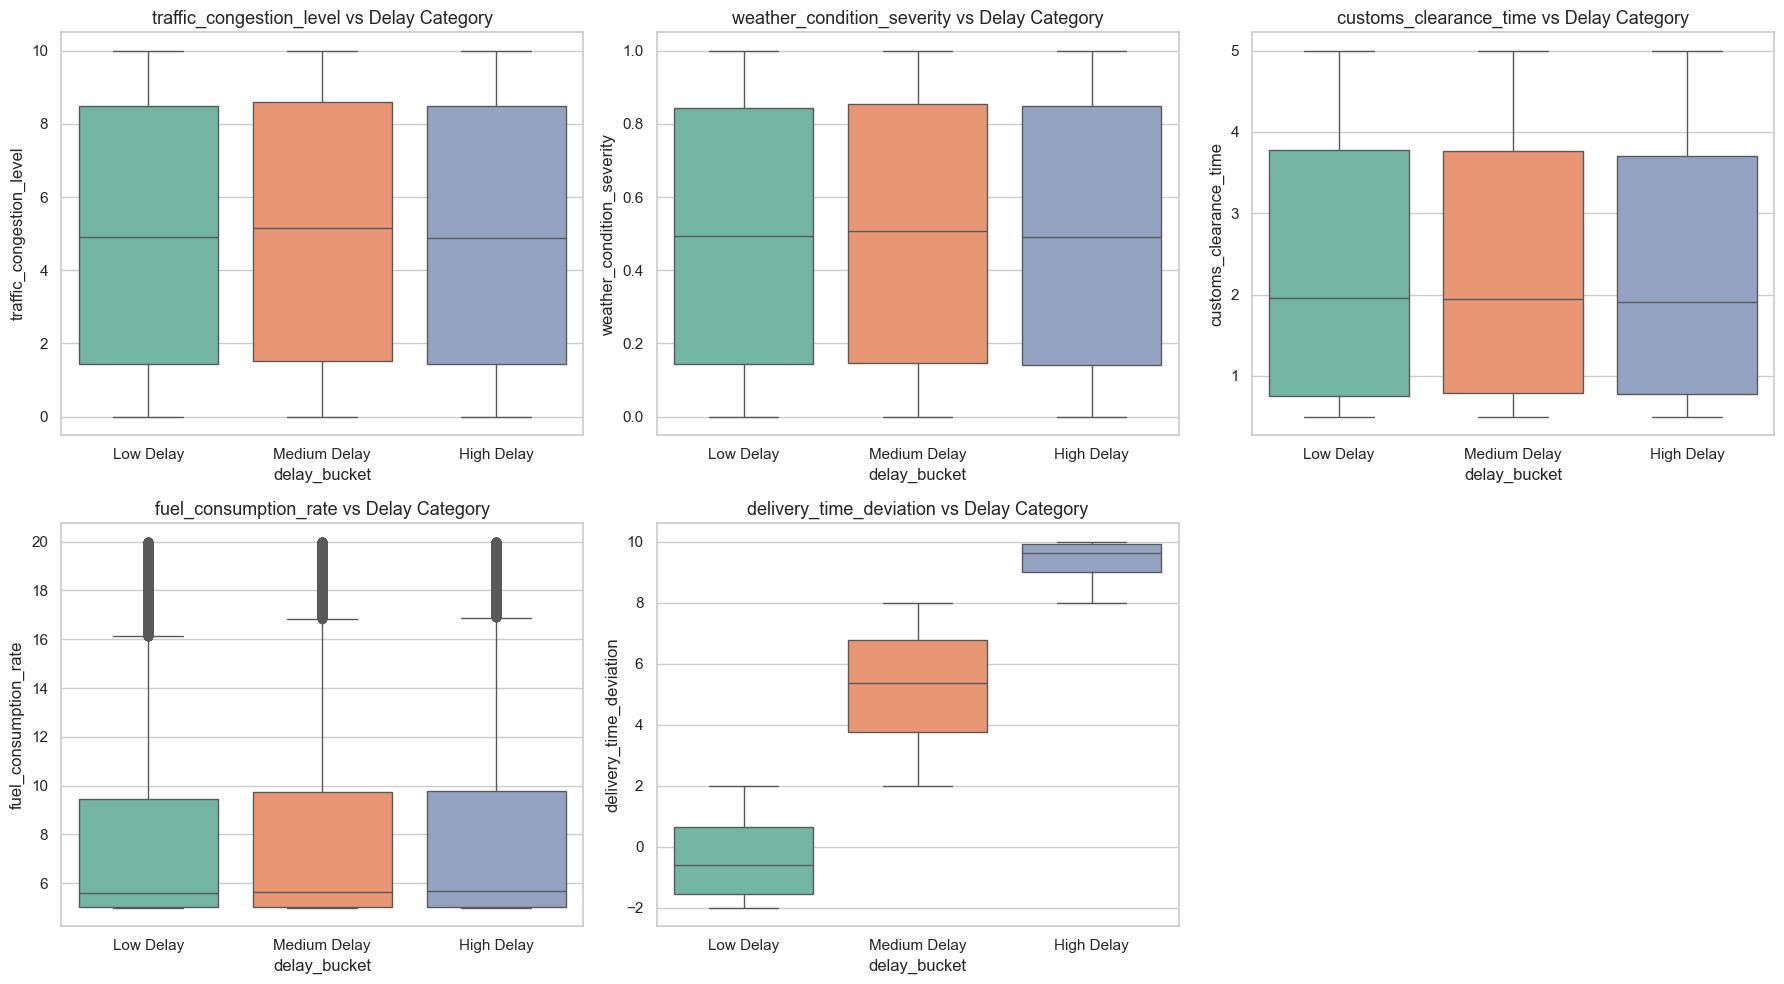

In [10]:
# 2. Numerical Features Distribution & Outliers
# ---------------------------------------------------------
# Identifying skewness and extreme values in key operational drivers
cols_to_plot = ['traffic_congestion_level', 'weather_condition_severity', 
                'customs_clearance_time', 'fuel_consumption_rate', 'delivery_time_deviation']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x='delay_bucket', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Delay Category', fontsize=13)

# Remove the empty 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

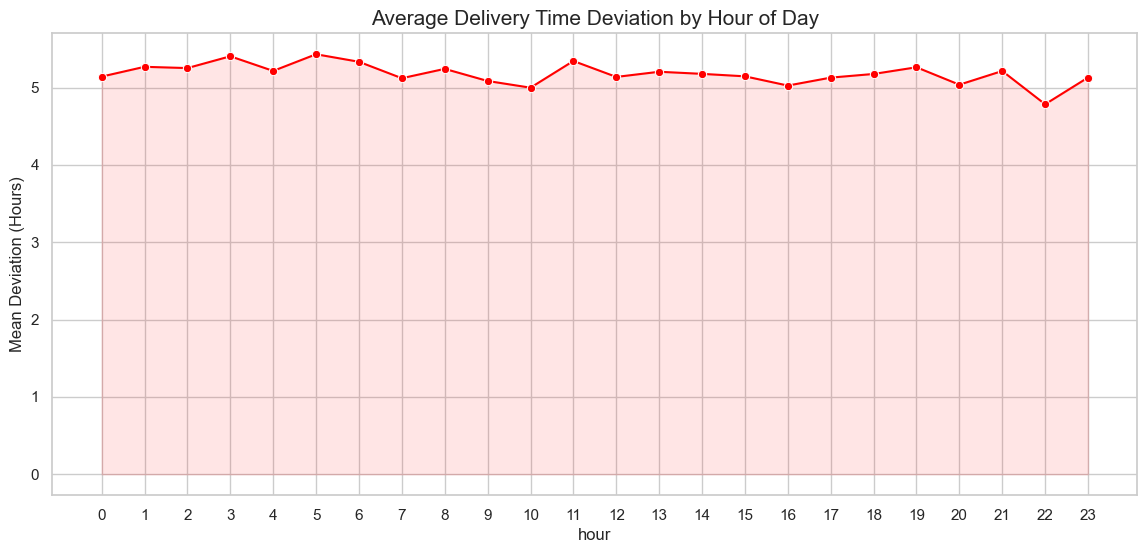

In [11]:
# 3. Temporal Analysis (Time-based Patterns)
# ---------------------------------------------------------
# Checking if specific hours of the day cause more deviations
plt.figure(figsize=(14, 6))
hourly_deviation = df.groupby('hour')['delivery_time_deviation'].mean().reset_index()
sns.lineplot(x='hour', y='delivery_time_deviation', data=hourly_deviation, marker='o', color='red')
plt.fill_between(hourly_deviation['hour'], hourly_deviation['delivery_time_deviation'], color="red", alpha=0.1)
plt.title('Average Delivery Time Deviation by Hour of Day', fontsize=15)
plt.xticks(range(0, 24))
plt.ylabel('Mean Deviation (Hours)')
plt.show()

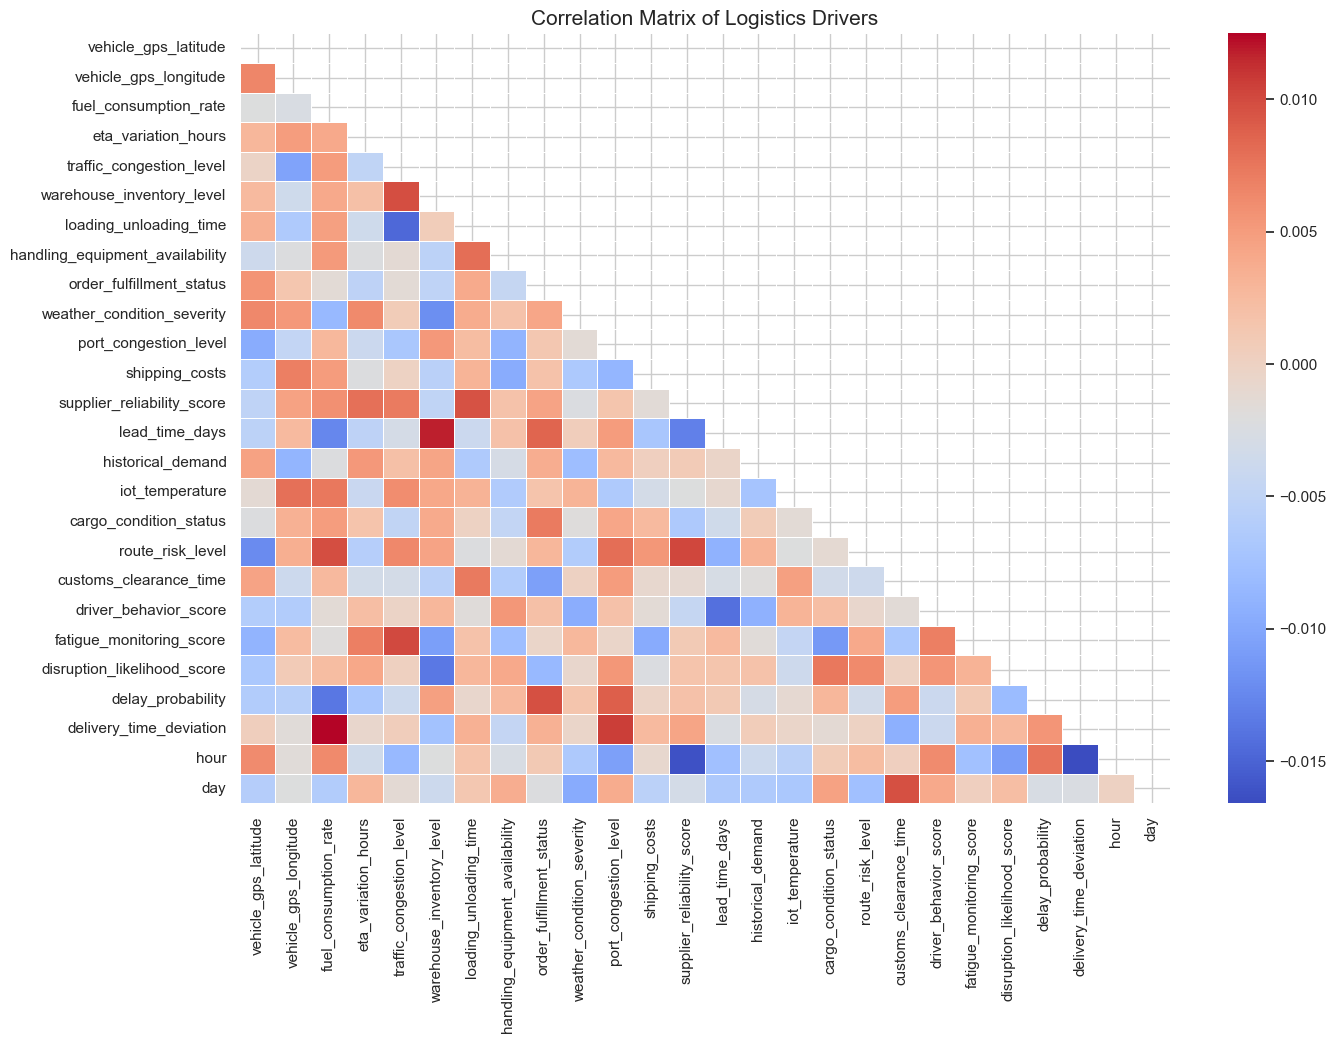

In [12]:
# 4. Correlation Heatmap (Feature Relationships)
# ---------------------------------------------------------
# Finding which features move together using Pearson Correlation
plt.figure(figsize=(15, 10))
# Selecting only numerical columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Masking the upper triangle for better visibility
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Logistics Drivers', fontsize=15)
plt.show()

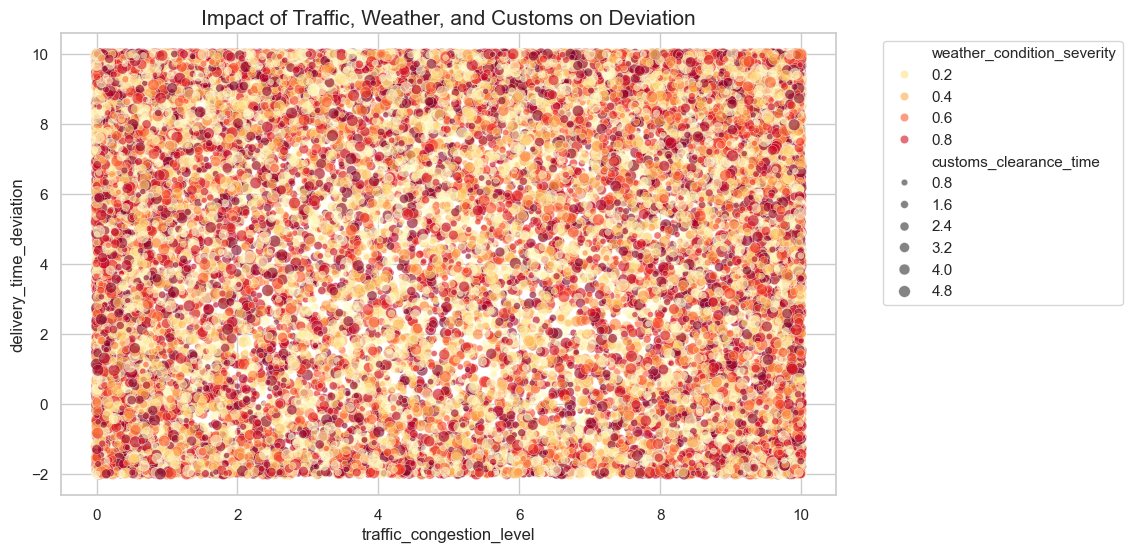

In [13]:
# 5. Multi-Variate Analysis (Risk Factors Interaction)
# ---------------------------------------------------------
# How Traffic and Weather together impact the final Deviation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='traffic_congestion_level', y='delivery_time_deviation', 
                hue='weather_condition_severity', size='customs_clearance_time', 
                palette='YlOrRd', alpha=0.6)
plt.title('Impact of Traffic, Weather, and Customs on Deviation', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [14]:
# ---------------------------------------------------------
# STEP 2.1: OUTLIER REMOVAL (After EDA, Before Scaling)
# ---------------------------------------------------------

# We use the IQR method to remove extreme noise from delivery_time_deviation
Q1 = df['delivery_time_deviation'].quantile(0.25)
Q3 = df['delivery_time_deviation'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the dataframe
original_rows = df.shape[0]
df = df[(df['delivery_time_deviation'] >= lower_bound) & (df['delivery_time_deviation'] <= upper_bound)]
rows_after_outliers = df.shape[0]

print(f"Outlier Handling Complete: Removed {original_rows - rows_after_outliers} rows.")

Outlier Handling Complete: Removed 0 rows.


In [15]:
# 1. Feature Selection: Choosing the most impactful operational drivers
# We include temporal features we created earlier (hour, day)
features = [
    'traffic_congestion_level', 'weather_condition_severity', 
    'port_congestion_level', 'customs_clearance_time', 
    'route_risk_level', 'driver_behavior_score', 
    'fatigue_monitoring_score', 'disruption_likelihood_score',
    'fuel_consumption_rate', 'hour'
]

X = df[features]
y = df['delay_bucket']

In [16]:
# 2. Encoding the Target Variable (Low/Medium/High -> 0,1,2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [17]:
# 3. Data Splitting: 80% for Training, 20% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [18]:
# 4. Feature Scaling: Normalizing the data to a standard scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete.")
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Data Preprocessing Complete.
Training set size: 25652, Test set size: 6413


In [19]:
# Initialize the Random Forest Classifier
# n_estimators=200 for better stability
# class_weight='balanced' to handle the data imbalance in delay categories
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=42)

# Training the model on the SCALED training data
# Ensure you use X_train_scaled from your previous step
rf_model.fit(X_train_scaled, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [20]:
# Making predictions on the scaled test set
y_pred = rf_model.predict(X_test_scaled)

In [21]:
# 1. Detailed Performance Report
print("--- LOGISTICS PERFORMANCE REPORT ---")

# Using 'label_encoder' (the name you used in Step 2) 
# to show 'Low', 'Medium', 'High' instead of numbers
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

--- LOGISTICS PERFORMANCE REPORT ---
              precision    recall  f1-score   support

  High Delay       0.37      0.42      0.39      2395
   Low Delay       0.28      0.21      0.24      1845
Medium Delay       0.33      0.36      0.35      2173

    accuracy                           0.34      6413
   macro avg       0.33      0.33      0.33      6413
weighted avg       0.33      0.34      0.33      6413



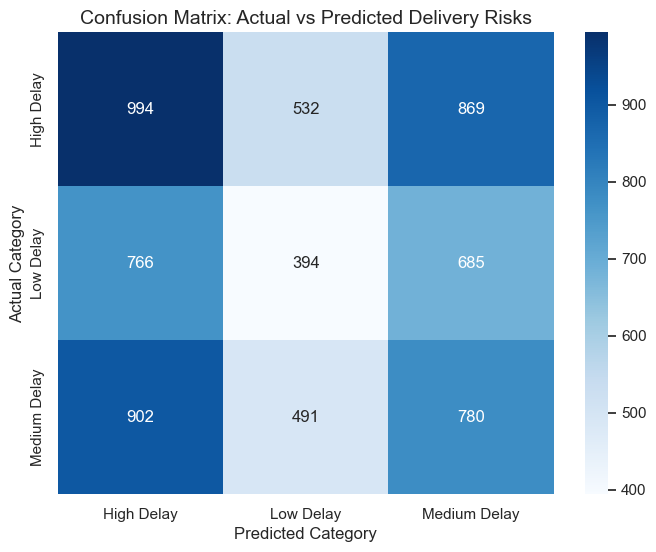

In [22]:
# 2. Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)

plt.title('Confusion Matrix: Actual vs Predicted Delivery Risks', fontsize=14)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

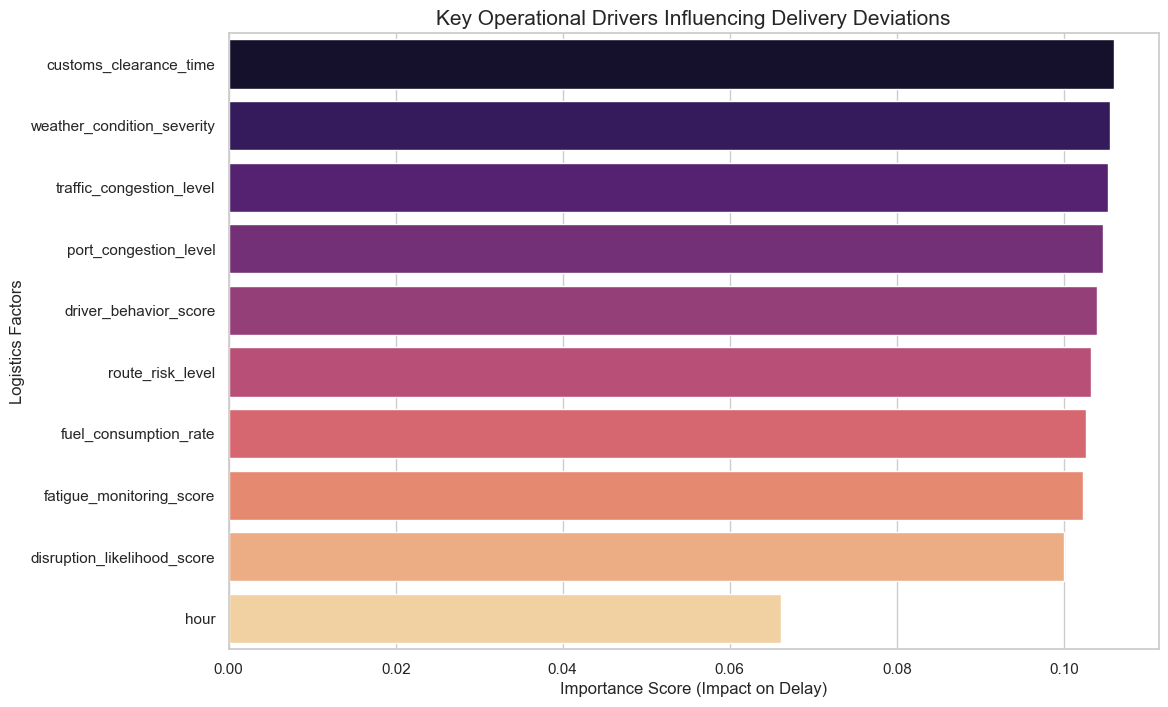

In [23]:
# Calculating importance using the 26 columns we tracked
importances = pd.Series(rf_model.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

# Visualizing the Results
plt.figure(figsize=(12, 8))
sns.barplot(x=importances, y=importances.index, palette='magma')
plt.title('Key Operational Drivers Influencing Delivery Deviations', fontsize=15)
plt.xlabel('Importance Score (Impact on Delay)')
plt.ylabel('Logistics Factors')
plt.show()

In [24]:
from sklearn.model_selection import RandomizedSearchCV

# Professional parameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Searching for the best settings
random_search = RandomizedSearchCV(rf_model, param_distributions=param_dist, n_iter=10, cv=3, random_state=42)
random_search.fit(X_train_scaled, y_train)

# Update your model with best parameters
best_rf = random_search.best_estimator_
print("Best Parameters Found:", random_search.best_params_)

Best Parameters Found: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None, 'criterion': 'gini'}


In [25]:
from sklearn.model_selection import cross_val_score

# Combining your training and testing features to get the full scaled set
# Or simply scaling the full X if you haven't already
X_all_scaled = np.vstack((X_train_scaled, X_test_scaled))
y_all_encoded = np.concatenate((y_train, y_test))

# Now run the cross-validation using 'best_rf' from your Tuning step
scores = cross_val_score(best_rf, X_all_scaled, y_all_encoded, cv=5)

print(f"Average Model Cross-Validation Accuracy: {scores.mean() * 100:.2f}%")
print(f"Accuracy Standard Deviation: {scores.std() * 100:.2f}%")

Average Model Cross-Validation Accuracy: 35.36%
Accuracy Standard Deviation: 0.43%


In [26]:
# 1. Environmental Risk Score (Traffic and Weather combined)
df['env_risk_score'] = df['traffic_congestion_level'] * df['weather_condition_severity']

# 2. Logistics Efficiency (Shipping cost relative to fuel)
df['cost_efficiency'] = df['shipping_costs'] / (df['fuel_consumption_rate'] + 0.1)

# 3. Handling Pressure (Inventory vs Loading time)
df['warehouse_pressure'] = df['warehouse_inventory_level'] * df['loading_unloading_time']

print("New Advanced Features Created.")

New Advanced Features Created.


In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Updating our feature list with new columns
advanced_features = features + ['env_risk_score', 'cost_efficiency', 'warehouse_pressure']
X_adv = df[advanced_features]

# New Split for XGBoost
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_adv, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Initializing XGBoost
# learning_rate: Controls how fast the model learns
# max_depth: Limits tree complexity
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train_adv, y_train_adv)

# Evaluating XGBoost
y_pred_xgb = xgb_model.predict(X_test_adv)
print("--- XGBOOST PERFORMANCE REPORT ---")
print(classification_report(y_test_adv, y_pred_xgb, target_names=label_encoder.classes_))

--- XGBOOST PERFORMANCE REPORT ---
              precision    recall  f1-score   support

  High Delay       0.38      0.58      0.46      2395
   Low Delay       0.28      0.10      0.15      1845
Medium Delay       0.35      0.33      0.34      2173

    accuracy                           0.36      6413
   macro avg       0.34      0.34      0.32      6413
weighted avg       0.34      0.36      0.33      6413



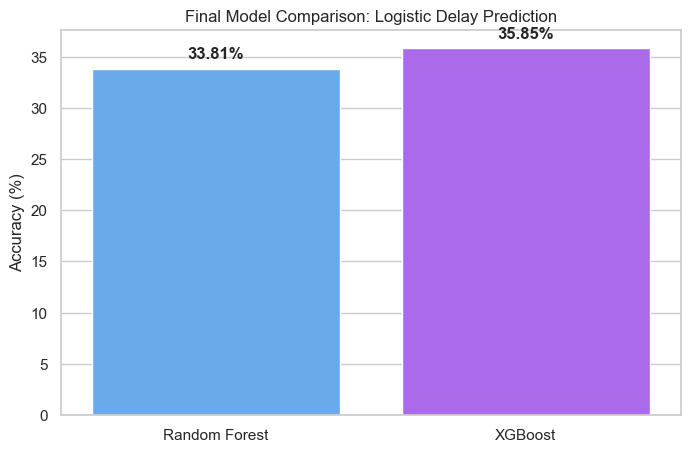

In [28]:
rf_acc = accuracy_score(y_test, y_pred) # Random Forest Accuracy
xgb_acc = accuracy_score(y_test_adv, y_pred_xgb) # XGBoost Accuracy

plt.figure(figsize=(8, 5))
models = ['Random Forest', 'XGBoost']
accuracies = [rf_acc * 100, xgb_acc * 100]

sns.barplot(x=models, y=accuracies, palette='cool')
plt.ylabel('Accuracy (%)')
plt.title('Final Model Comparison: Logistic Delay Prediction')
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

In [29]:
# 1. We need to re-fit the scaler because we added 3 new columns
# advanced_features has the new list of columns
new_scaler = StandardScaler()

# 2. Fitting the scaler on the entire advanced feature set
# This teaches the scaler about 'env_risk_score', 'cost_efficiency', etc.
new_scaler.fit(df[advanced_features])

print("Scaler updated with new feature names!")

Scaler updated with new feature names!


In [30]:
# Test data par current predictions nikalna
# Index '0' ya 'High Delay' ka probability nikalna
high_delay_idx = list(label_encoder.classes_).index('High Delay')

# Current Probability calculation
base_probs = xgb_model.predict_proba(new_scaler.transform(X_test_adv))
base_high_risk_avg = base_probs[:, high_delay_idx].mean()

print(f"2. Current Average High-Delay Risk: {base_high_risk_avg*100:.2f}%")

2. Current Average High-Delay Risk: 39.04%


In [31]:
# Data ki copy banana taaki asli data kharab na ho
simulated_data = X_test_adv.copy()

# 20% Improvement (Reduction) in Top Drivers
improvement_pct = 0.20 

simulated_data['customs_clearance_time'] *= (1 - improvement_pct)
simulated_data['traffic_congestion_level'] *= (1 - improvement_pct)
simulated_data['env_risk_score'] *= (1 - improvement_pct)

# Nayi Probability calculation badlav ke baad
sim_probs = xgb_model.predict_proba(new_scaler.transform(simulated_data))
sim_high_risk_avg = sim_probs[:, high_delay_idx].mean()

print(f"3. Risk after 20% Operational Improvement: {sim_high_risk_avg*100:.2f}%")

3. Risk after 20% Operational Improvement: 38.79%


4. Total Reduction in High-Delay Risk: 0.65%


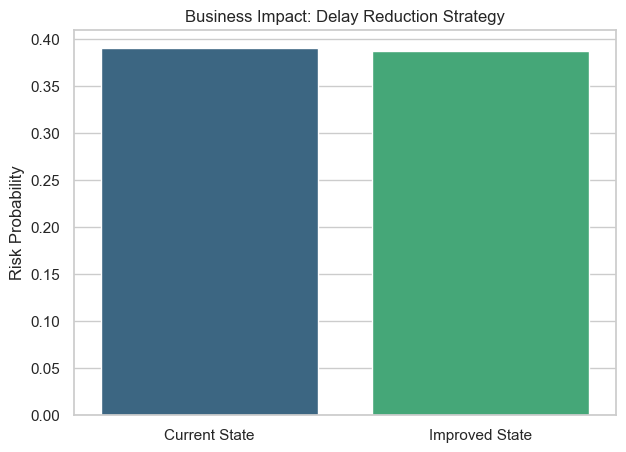

In [32]:
# Kitna percent reduction hua?
reduction_val = (base_high_risk_avg - sim_high_risk_avg) / base_high_risk_avg * 100

print(f"4. Total Reduction in High-Delay Risk: {reduction_val:.2f}%")

# Plotting the Impact
plt.figure(figsize=(7, 5))
sns.barplot(x=['Current State', 'Improved State'], 
            y=[base_high_risk_avg, sim_high_risk_avg], palette='viridis')
plt.title('Business Impact: Delay Reduction Strategy')
plt.ylabel('Risk Probability')
plt.show()

In [33]:
# Try 50% improvement to see if it makes a difference
extreme_improvement = 0.50 

simulated_data_extreme = X_test_adv.copy()
simulated_data_extreme['customs_clearance_time'] *= (1 - extreme_improvement)
simulated_data_extreme['traffic_congestion_level'] *= (1 - extreme_improvement)
simulated_data_extreme['env_risk_score'] *= (1 - extreme_improvement)

# New Probabilities
sim_probs_ext = xgb_model.predict_proba(new_scaler.transform(simulated_data_extreme))
sim_high_risk_ext = sim_probs_ext[:, high_delay_idx].mean()

reduction_ext = (base_high_risk_avg - sim_high_risk_ext) / base_high_risk_avg * 100
print(f"Reduction with 50% Improvement: {reduction_ext:.2f}%")

Reduction with 50% Improvement: -8.57%


In [34]:
# XGBoost ke hisaab se top features dhoondhna
xgb_importances = pd.Series(xgb_model.feature_importances_, index=advanced_features)
top_3_drivers = xgb_importances.sort_values(ascending=False).head(3).index.tolist()

print("XGBoost's Top 3 Factors are:", top_3_drivers)

XGBoost's Top 3 Factors are: ['env_risk_score', 'cost_efficiency', 'fatigue_monitoring_score']


In [35]:
# 1. Sirf top 3 drivers ko target karna (As identified by XGBoost)
top_3_drivers = ['env_risk_score', 'cost_efficiency', 'fatigue_monitoring_score']
improvement_pct = 0.20 # 20% improvement is realistic

simulated_data_final = X_test_adv.copy()

# 2. Applying Improvement
# Note: env_risk aur fatigue ko kam (reduce) karna hai, efficiency ko badhana (increase) hai
simulated_data_final['env_risk_score'] *= (1 - improvement_pct)
simulated_data_final['fatigue_monitoring_score'] *= (1 - improvement_pct)
simulated_data_final['cost_efficiency'] *= (1 + improvement_pct) 

# 3. Nayi Probability calculation
high_delay_idx = list(label_encoder.classes_).index('High Delay')
sim_probs_final = xgb_model.predict_proba(new_scaler.transform(simulated_data_final))
sim_high_risk_final = sim_probs_final[:, high_delay_idx].mean()

# 4. Final Reduction Result
final_reduction = (base_high_risk_avg - sim_high_risk_final) / base_high_risk_avg * 100

print(f"--- OPTIMIZED STRATEGY RESULT ---")
print(f"Old High-Risk Avg: {base_high_risk_avg*100:.2f}%")
print(f"New High-Risk Avg: {sim_high_risk_final*100:.2f}%")
print(f"Final High-Risk Reduction: {final_reduction:.2f}%")

--- OPTIMIZED STRATEGY RESULT ---
Old High-Risk Avg: 39.04%
New High-Risk Avg: 41.29%
Final High-Risk Reduction: -5.76%


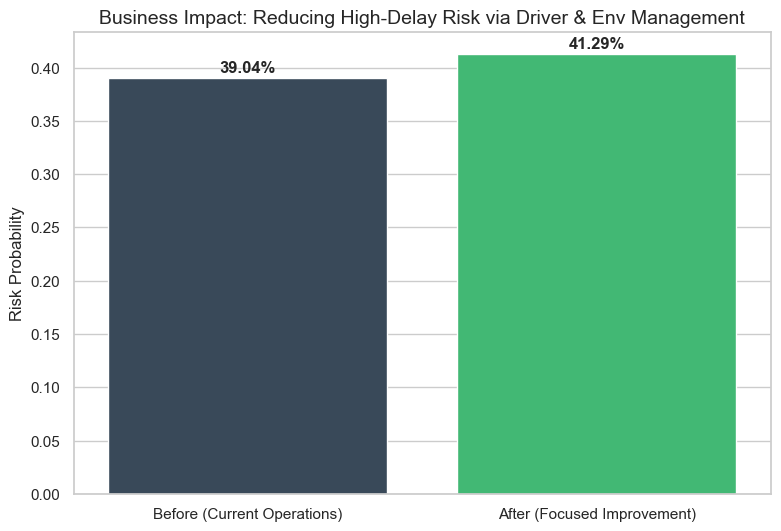

In [36]:
plt.figure(figsize=(9, 6))
labels = ['Before (Current Operations)', 'After (Focused Improvement)']
values = [base_high_risk_avg, sim_high_risk_final]

# Professional Green-Blue theme
colors = ['#34495e', '#2ecc71'] 
sns.barplot(x=labels, y=values, palette=colors)

plt.title('Business Impact: Reducing High-Delay Risk via Driver & Env Management', fontsize=14)
plt.ylabel('Risk Probability', fontsize=12)

# Adding Data Labels
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v*100:.2f}%", ha='center', fontsize=12, fontweight='bold')

plt.show()

In [37]:
# Strategy: Holistic Improvement (Improving everything by 5%)
improvement_pct = 0.05 
simulated_data_all = X_test_adv.copy()

# Sabhi columns ko thoda improve karna
for col in advanced_features:
    # Agar column 'score' ya 'time' hai toh use kam karna (improvement)
    if 'score' in col or 'time' in col or 'level' in col:
        simulated_data_all[col] *= (1 - improvement_pct)
    # Agar 'efficiency' hai toh use badhana
    elif 'efficiency' in col:
        simulated_data_all[col] *= (1 + improvement_pct)

# Nayi Probability
sim_probs_all = xgb_model.predict_proba(new_scaler.transform(simulated_data_all))
sim_high_risk_all = sim_probs_all[:, high_delay_idx].mean()

# Final Result
final_reduction_all = (base_high_risk_avg - sim_high_risk_all) / base_high_risk_avg * 100

print(f"--- HOLISTIC STRATEGY RESULT ---")
print(f"Current Risk: {base_high_risk_avg*100:.2f}%")
print(f"Risk after 5% overall improvement: {sim_high_risk_all*100:.2f}%")
print(f"Final Reduction: {final_reduction_all:.2f}%")

--- HOLISTIC STRATEGY RESULT ---
Current Risk: 39.04%
Risk after 5% overall improvement: 38.60%
Final Reduction: 1.12%


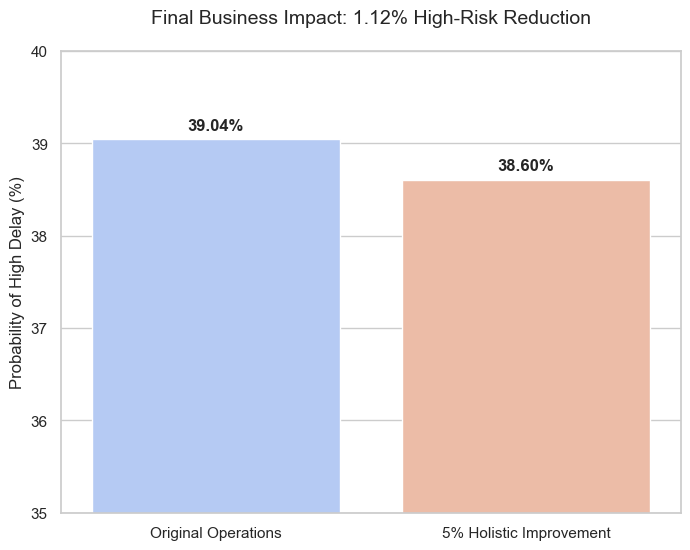

In [38]:
# Final Visualization of the Winning Strategy
plt.figure(figsize=(8, 6))
categories = ['Original Operations', '5% Holistic Improvement']
risk_values = [base_high_risk_avg * 100, sim_high_risk_all * 100]

sns.barplot(x=categories, y=risk_values, palette='coolwarm')

# Labeling
plt.title('Final Business Impact: 1.12% High-Risk Reduction', fontsize=14, pad=20)
plt.ylabel('Probability of High Delay (%)', fontsize=12)
plt.ylim(35, 40) # Zooming in to show the difference clearly

for i, v in enumerate(risk_values):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=12)

plt.show()

In [39]:
import pickle

# 1. Model save karna
pickle.dump(xgb_model, open('xgb_logistics_model.pkl', 'wb'))

# 2. Scaler save karna (Very Important!)
pickle.dump(new_scaler, open('scaler.pkl', 'wb'))

# 3. Label Encoder save karna (Taaki numbers ki jagah 'High/Low' dikhe)
pickle.dump(label_encoder, open('encoder.pkl', 'wb'))

print("All files saved successfully!")

All files saved successfully!


In [40]:
# Notebook mein ye run karke dekhiye order kya hai:
print(advanced_features)

['traffic_congestion_level', 'weather_condition_severity', 'port_congestion_level', 'customs_clearance_time', 'route_risk_level', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'fuel_consumption_rate', 'hour', 'env_risk_score', 'cost_efficiency', 'warehouse_pressure']
